<a href="https://colab.research.google.com/github/TanyaGandhi/ai-debugging-rca-platform/blob/feature/ai_debugging_rca_platform.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#AI-Powered Microservice Debugging & RCA Platform

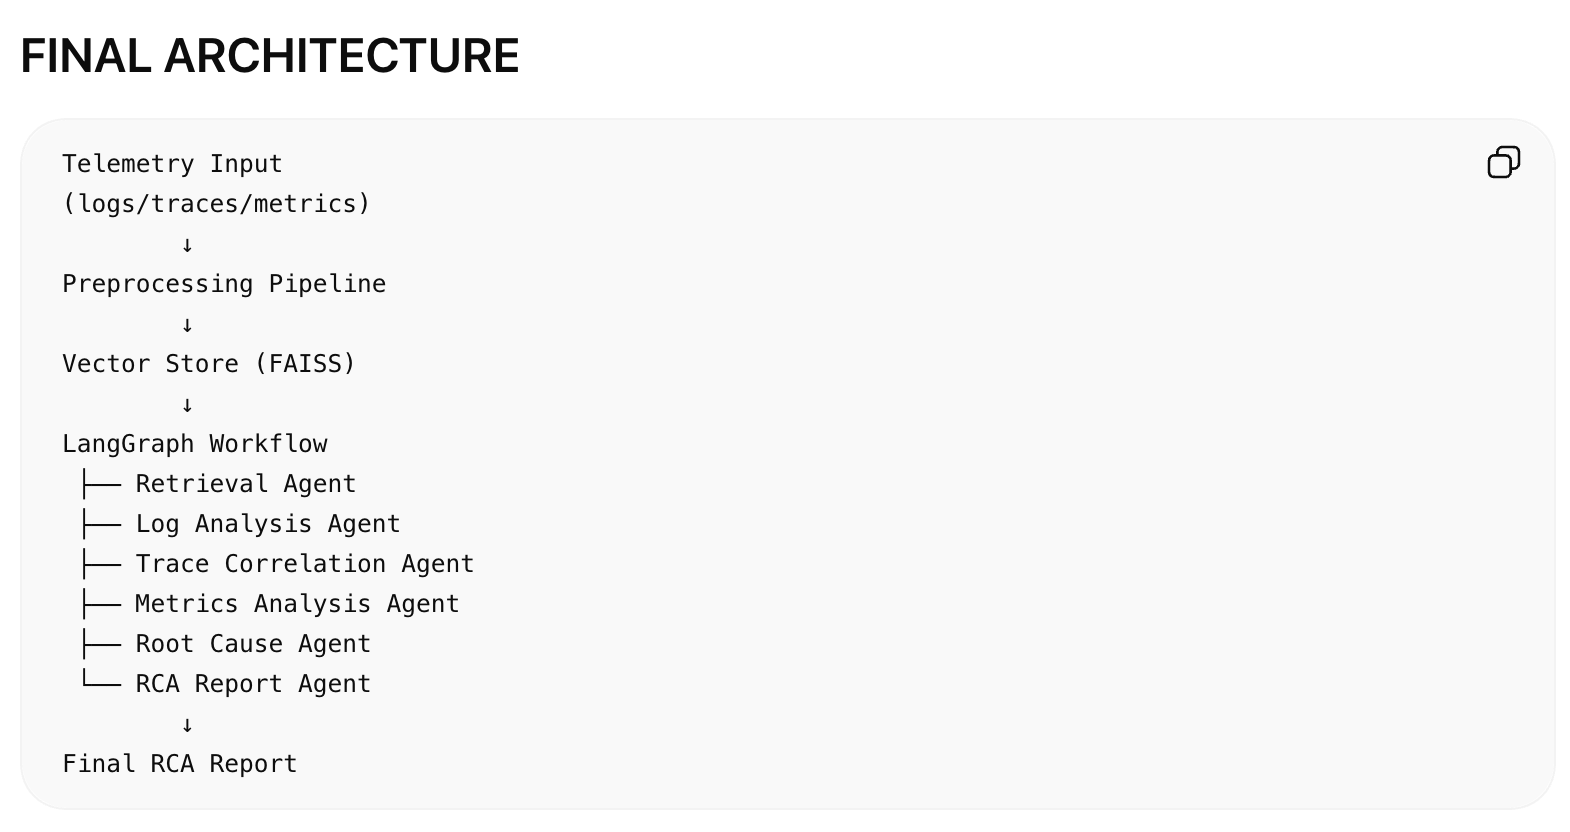

**SECTION 1 — Install Packages**

In [1]:
!pip install -q \
langchain \
langgraph \
langchain-google-genai \
faiss-cpu \
pydantic \
pandas \
numpy \
tiktoken \
fastapi \
uvicorn \
python-dotenv

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 67.6/67.6 kB 2.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.8/23.8 MB 57.5 MB/s eta 0:00:00


In [2]:
!pip install -q pinecone langchain-pinecone

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 587.6/587.6 kB 11.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 98.6/98.6 kB 3.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 548.1/548.1 kB 13.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.6/16.6 MB 34.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 259.3/259.3 kB 8.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 65.5/65.5 kB 2.3 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
numba 0.60.0 requires numpy<2.1,>=1.22, but you have numpy 2.4.5 which is incompatible.


**Configure Gemini**

In [3]:
import os
from google.colab import userdata
import google.genai as genai
from pinecone import Pinecone, ServerlessSpec
from langchain_pinecone import PineconeVectorStore
os.environ["GOOGLE_API_KEY"] = userdata.get("GOOGLE_API_KEY")
client = genai.Client(api_key=os.environ["GOOGLE_API_KEY"])
os.environ["PINECONE_API_KEY"] = userdata.get("PINE_CONE_BHUMI_10P99")

**Create Gemini Model**

In [4]:
from langchain_google_genai import ChatGoogleGenerativeAI
llm = ChatGoogleGenerativeAI(
    model ="gemini-2.5-flash",
    temperature = 0
)

**SECTION 2 — Build Realistic Telemetry Generator**

In [5]:
#Example Log Dataset
logs = [
    {
        "timestamp": "2026-05-15T10:01:00",
        "service": "payment-service",
        "level": "ERROR",
        "message": "Database connection timeout"
    },
    {
        "timestamp": "2026-05-15T10:01:02",
        "service": "order-service",
        "level": "ERROR",
        "message": "Payment processing failed"
    }
]
#Example Trace Dataset
traces = [
    {
        "trace_id": "abc123",
        "source": "api-gateway",
        "destination": "payment-service",
        "latency_ms": 4200,
        "status": "TIMEOUT"
    }
]
#Example Metrics Dataset
metrics = [
    {
        "service": "payment-service",
        "cpu_usage": 92,
        "memory_usage": 88,
        "error_rate": 34
    }
]
#Example Stack Trace Dataset
stack_traces = [
    {
        "service": "payment-service",
        "stack_trace": """
        ConnectionPoolExhaustedException:
        Unable to acquire JDBC
        """
    }
      ]

Create Service Dependency Graph

In [6]:
SERVICE_GRAPH = {
    "api-gateway" : ["auth-service", "order-service"],
    "order-service" : ["payment-service", "inventory-service"],
    "payment-service": ["db-service"],
    "inventory-service": ["db-service"],
    "auth-service": ["redis-cache"]
}

Generate Synthetic Failures

In [7]:
import random
from datetime import datetime, timezone # Add timezone here
import uuid

SERVICES = [
    "api-gateway",
    "auth-service",
    "order-service",
    "payment-service",
    "inventory-service",
    "db-service"
]

ERROR_PATTERNS = [
    "Database connection timeout",
    "Connection pool exhausted",
    "Kafka consumer lag exceeded threshold",
    "HTTP 503 Service Unavailable",
    "Redis cache miss spike",
    "gRPC request timeout",
    "Thread pool saturation",
    "Out of memory error"
]

Generate Logs

In [8]:
def generate_logs(num_log=200):
  logs = []
  for _ in range(num_log):
    service = random.choice(SERVICES)
    is_error = random.random() < 0.3
    logs.append(
        {
            "timestamp" :  str(datetime.now(timezone.utc)),
            "trace_id":  str(uuid.uuid4()),
            "service": service,
            "level": "ERROR" if is_error else "INFO",
            "message": random.choice(ERROR_PATTERNS) if is_error else "Request processed successfully"
        }
    )
    return logs

 Generate Distributed Traces

In [9]:
def generate_traces(num_traces =100):
  traces = []
  for _ in range(num_traces):
    source = random.choice(list(SERVICE_GRAPH.keys()))
    if SERVICE_GRAPH.get(source):
      destination = random.choice(SERVICE_GRAPH.get(source))
    else:
      destination = "unknown"
    latency = random.randint(10,5000)
    traces.append(
        {
            "trace_id": str(uuid.uuid4()),
            "source" : source,
            "destination": destination,
            "latency_ms": latency,
            "status": "TIMEOUT" if latency > 3000 else "SUCCESS"
        }
    )
    return traces



Generate Metrics

In [10]:
def generate_metrics():
  metrics = []
  for service in SERVICES:

    cpu = random.randint(20,98)
    metrics.append({
        "service": service,
        "cpu": cpu,
        "memory_usage": random.randint(20,95),
        "error_rate": random.randint(0,40),
        "request_count": random.randint(100,5000),
        "p95_latency": random.randint(50,4000)
    })

  return metrics


Generate Stack Traces

In [11]:
STACK_TRACES = [
    """
    java.sql.SQLTimeoutException:
    Connection pool exhausted
    at payment.service.DatabaseConnector.getConnection
    """,

    """
    NullPointerException:
    order object is null
    at OrderProcessor.processOrder
    """,

    """
    KafkaTimeoutException:
    Failed to update metadata
    """
]

def generate_stack_traces():
    traces = []

    for _ in range(20):

        traces.append({
            "service": random.choice(SERVICES),
            "stack_trace": random.choice(STACK_TRACES)
        })

    return traces

Create Telemetry Dataset

In [12]:
logs = generate_logs()
traces = generate_traces()
metrics = generate_metrics()
stack_traces = generate_stack_traces()

Save Datasets

In [13]:
import json

with open("logs.json", "w") as f:
    json.dump(logs, f)

with open("traces.json", "w") as f:
    json.dump(traces, f)

with open("metrics.json", "w") as f:
    json.dump(metrics, f)

with open("stack_traces.json", "w") as f:
    json.dump(stack_traces, f)

**SECTION 3 — Build RAG Pipeline**

Install Embedding Support

In [14]:
!pip install -q langchain-community

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 40.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 44.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.1/73.1 kB 4.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.0/51.0 kB 3.1 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires requests==2.32.4, but you have requests 2.34.2 which is incompatible.


Create Documents

In [15]:
from langchain_core.documents import Document

documents = []

for log in logs:
    documents.append(
        Document(
            page_content=str(log),
            metadata={"type": "log"}
        )
    )

for trace in stack_traces:
    documents.append(
        Document(
            page_content=str(trace),
            metadata={"type": "stack_trace"}
        )
    )

 Add Troubleshooting KB

In [16]:
kb_docs = [
    """
    Database connection timeout usually occurs due to:
    - exhausted DB pool
    - slow queries
    - network latency
    Recommended actions:
    increase pool size,
    optimize queries,
    add retries
    """,

    """
    Kafka consumer lag occurs due to:
    - slow consumers
    - broker overload
    - partition imbalance
    Recommended fixes:
    scale consumers,
    tune batch size
    """
]

for kb in kb_docs:
    documents.append(
        Document(
            page_content=kb,
            metadata={"type": "kb"}
        )
    )

Create Gemini Embeddings

In [17]:
from langchain_google_genai import GoogleGenerativeAIEmbeddings
embeddings = GoogleGenerativeAIEmbeddings(model="models/gemini-embedding-001")

Create PineCone Vector database

In [18]:
pc = Pinecone(api_key = os.environ["PINECONE_API_KEY"])
INDEX_NAME ="microservice-debugging"

# Check if index exists and delete it to ensure correct dimension
if INDEX_NAME in [index_info["name"] for index_info in pc.list_indexes()]:
    print(f"Deleting existing index '{INDEX_NAME}' to recreate with correct dimension.")
    pc.delete_index(INDEX_NAME)

# Create the index with the correct dimension (3072)
pc.create_index(
    name = INDEX_NAME,
    dimension = 3072,
    metric= "cosine",
    spec = ServerlessSpec(
        cloud = "aws",
        region="us-east-1"
    )
)

index = pc.Index(INDEX_NAME)
vector_store = PineconeVectorStore(index=index, embedding = embeddings)
vector_store.add_documents(documents)

Deleting existing index 'microservice-debugging' to recreate with correct dimension.


['cb79ac47-c229-474e-b433-8b7126da8600',
 '2b7aba4e-3f28-4a81-a0cf-404ae3a1ead4',
 '27f48d70-d220-4407-8e41-7471079fdb5f',
 '5e51c265-c638-448a-89d7-deeef25feacb',
 '344e69f2-8ab0-4bd3-a2e6-ab462d4125a2',
 'df336279-4282-4263-8882-287fb1da2b12',
 'a5387d71-17b6-4f63-8bf3-ceaebdb6f21d',
 '0fd60d5a-060e-4d93-a5ce-5b5779f621ec',
 'f0f5ee25-1456-454e-8667-e37f8bb4126b',
 'd2c2a4b2-4051-4fd8-9565-f8ce953b7f86',
 '43832129-4e56-412d-96ef-551c0be285c9',
 '43bad2a5-6c74-48a1-9ce7-a83d2c4ad3a7',
 '49edb4ad-9939-4ead-97b3-1ba5563eb932',
 '9158828d-98a3-41ed-bae2-41f9f1850da4',
 '317d2119-dcc7-47a1-962c-929e8f55aea7',
 '42fcc83d-267e-4217-8408-e773c1dfcc75',
 'dfe28e57-878e-40b5-9ffd-8dc8bbc1338f',
 '96352884-13c8-4842-bfb7-21c68ecb0213',
 '1e611c80-d76e-492e-bdaf-7c717ee0e733',
 '9dda0280-55bc-4e72-ba2e-79bb6f157af6',
 'aae47114-28d2-4585-a63e-7f73333402da',
 '1907fe8b-87bd-4415-bb22-ef6aa7d595af',
 'ceb975c9-36af-4a6f-a31c-9a7a3e3a15dc']

Create Retriever(Including metadata filtering)

In [19]:
retriever = vector_store.as_retriever(
         search_type = "similarity",
         search_kwargs = {"k" : 5, "filter": {"type": "kb" }}
)


Test Retrieval

In [20]:
query = "payment service database timeout"

results = retriever.invoke(query)

for i, result in enumerate(results):

    print(f"\nRESULT {i+1}")
    print(result.page_content)
    print("-" * 80)


RESULT 1

    Database connection timeout usually occurs due to:
    - exhausted DB pool
    - slow queries
    - network latency
    Recommended actions:
    increase pool size,
    optimize queries,
    add retries
    
--------------------------------------------------------------------------------

RESULT 2

    Kafka consumer lag occurs due to:
    - slow consumers
    - broker overload
    - partition imbalance
    Recommended fixes:
    scale consumers,
    tune batch size
    
--------------------------------------------------------------------------------


#FINAL PHASE 4 ARCHITECTURE



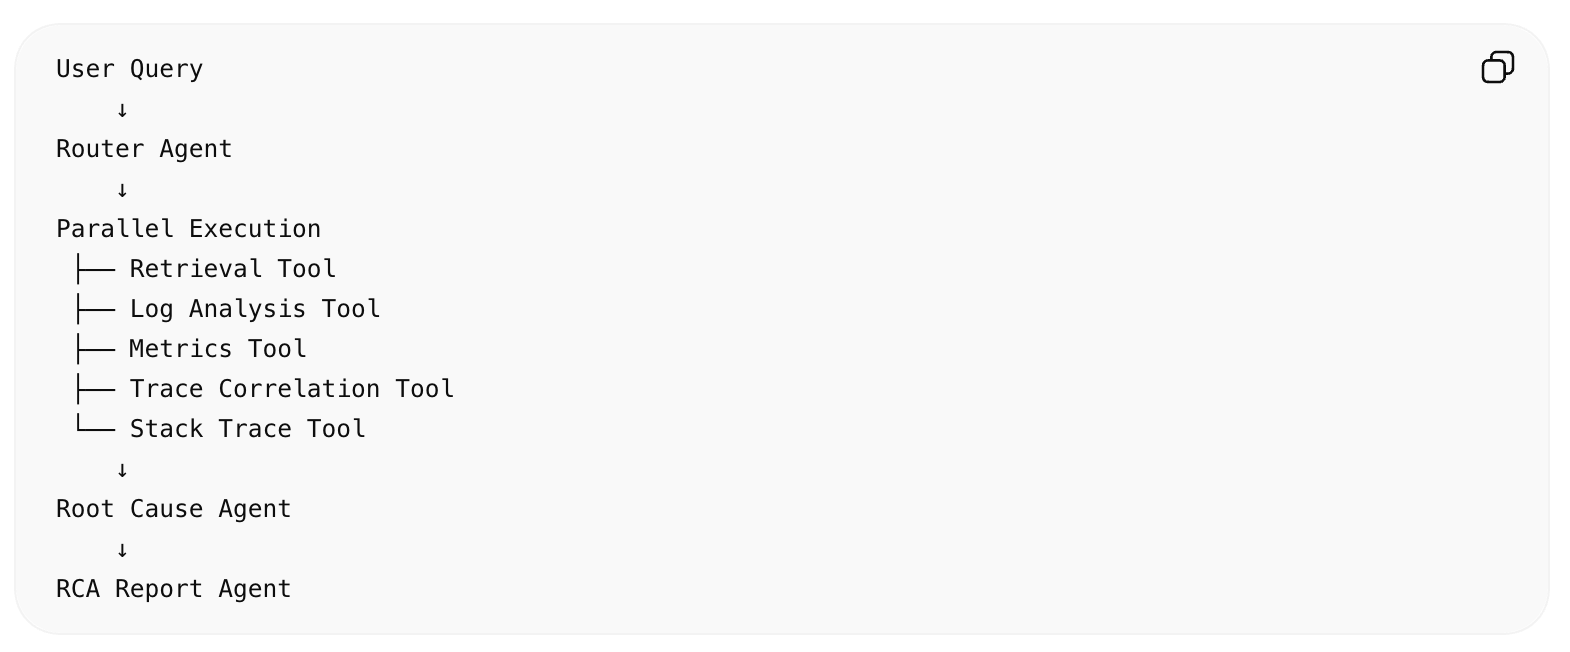

Create Shared State

In [21]:
from typing import TypedDict, Dict,List, Any
from pydantic import BaseModel, Field

class DebuggingState(TypedDict):
  user_query: str
  retrieved_docs: List[str]
  log_analysis: str
  trace_analysis: str
  metrics_analysis: str
  stacktrace_analysis: str
  root_cause: str
  recommendations: str
  final_report: str


Build Retrieval Tool

This tool fetches:

logs

KB docs

stack traces

In [22]:
from langchain_core.tools import StructuredTool # Corrected import path

def _retrieval_tool_func(user_query: str) -> dict:
  """Retrieves relevant documents based on the user's query string."""
  results = retriever.invoke(user_query)

  retrieved_content = [ r.page_content for r in results]
  return {
      "retrieved_docs": retrieved_content
  }

retrieval_tool = StructuredTool.from_function(
    func=_retrieval_tool_func,
    name="retrieval_tool",
    description="Retrieves relevant documents based on the user's query string."
)

Build Log Analysis Tool

This tool analyzes:

failures

patterns

repeated errors

In [23]:
from langchain_core.prompts import PromptTemplate
from langchain.tools import tool

LOG_ANALYSIS_PROMPT = """
You are the senior SRE engineer. You are capable of analyzing the given logs and identifying the required data.
Logs: {logs}
Analyze the given telemetry logs stroed in input variable Logs .
Identify the following:
- possible failures
- suspicious patterns
- impacted services
- likely causes
"""
log_prompt = PromptTemplate(template =LOG_ANALYSIS_PROMPT, input_variables=["logs"])

@tool
def log_analysis_tool(state: DebuggingState):
  """Anaylizes the logs"""
  log = "\n".join(state["retrieved_docs"])
  chain = log_prompt | llm
  response = chain.invoke({"logs": log})
  return {
        "log_analysis": response.content
    }

/usr/local/lib/python3.12/dist-packages/langgraph/checkpoint/serde/encrypted.py:5: LangChainPendingDeprecationWarning: The default value of `allowed_objects` will change in a future version. Pass an explicit value (e.g., allowed_objects='messages' or allowed_objects='core') to suppress this warning.
  from langgraph.checkpoint.serde.jsonplus import JsonPlusSerializer


 Build Trace Correlation Tool

In [24]:
from langchain.tools import tool

TRACE_ANALYSIS_PROMPT = """
You are an expert distributed system engineer who is specialized in analysing the traces.

Traces = {traces}

Analyze the given traces stored in the input variable Traces.
Identify:
- latency bottlenecks
- failing downstream services
- timeout propagation
- dependency failures
"""
trace_prompt = PromptTemplate(template =TRACE_ANALYSIS_PROMPT, input_variables=["traces"])

@tool
def traces_analysis_tool(state: DebuggingState):
  """Anaylizes the traces"""
  traces = "\n".join(state["retrieved_docs"])
  chain = trace_prompt | llm
  response = chain.invoke({"traces": traces})
  return {
        "trace_analysis": response.content
    }

Build Metrics Analysis Tool

In [25]:
from langchain.tools import tool

METRICS_ANALYSIS_PROMPT = """
You are observalibilty expert.You are specialized in analyzing the metrics and identifying the required data.
Metrics = {metrics}
Focus on:
- CPU spikes
- memory pressure
- latency anomalies
- high error rates
- overloaded services
"""
metrics_prompt = PromptTemplate(template = METRICS_ANALYSIS_PROMPT, input_variables = ["metrics"])

@tool
def metrics_analysis_tool(state: DebuggingState):
  """Analyzes the metrics"""
  metrics = "\n".join(state["retrieved_docs"])
  chain = metrics_prompt | llm
  response = chain.invoke({"metrics": metrics})
  return {
        "metrics_analysis": response.content
    }

Build Stack Trace Analysis Tool

In [26]:
from langchain.tools import tool

STACKTRACE_PROMPT = """
You are a JVM debugging expert.

Analyze the stack traces below.

Identify:
- root exceptions
- probable causes
- failing components
- recovery recommendations

Stack Traces:
{stack_traces}
"""
stack_prompt = PromptTemplate(
    template=STACKTRACE_PROMPT,
    input_variables=["stack_traces"]
)

@tool
def stacktrace_analysis_tool(state: DebuggingState):
  """Analyzes the stack trace """

  traces_text = "\n".join(state["retrieved_docs"])

  chain = stack_prompt | llm

  response = chain.invoke({
        "stack_traces": traces_text
  })

  return {
        "stacktrace_analysis": response.content
    }

Build Root Cause Agent

In [27]:
from langchain.tools import tool

ROOT_CAUSE_PROMPT = """
You are principle site reliability engineer.

You have:
- log analysis
- trace analysis
- metrics analysis
- stacktrace analysis

Determine :
1. Most probable root cause
2. Impacted services
3. Failure propagation path
4. Severity level
5. Recommended remediations

Log Analysis : {log_analysis}
Trace Analysis : {trace_analysis}
Metrics Analysis : {metrics_analysis}
Stacktrace Analysis : {stacktrace_analysis}
"""
root_cause_prompt = PromptTemplate(
    template=ROOT_CAUSE_PROMPT,
    input_variables=["log_analysis", "trace_analysis", "metrics_analysis", "stacktrace_analysis"])

@tool
def root_cause_analysis_tool(state: DebuggingState):
  """Determines the root cause"""
  chain = root_cause_prompt | llm
  response = chain.invoke({
        "log_analysis": state["log_analysis"],
        "trace_analysis": state["trace_analysis"],
        "metrics_analysis": state["metrics_analysis"],
        "stacktrace_analysis": state["stacktrace_analysis"]
    })
  return {
        "root_cause": response.content
    }

Build RCA Report Generator

In [28]:
from langchain.tools import tool

RCA_PROMPT = """
Generate a production-grade Root Cause Analysis report.

Include:
- Incident Summary
- Root Cause
- Impact
- Affected Services
- Timeline
- Recommended Fixes
- Prevention Measures

Root Cause Analysis:
{root_cause}

Return the outpt in the following format as mentioned below:
Present each heading bold and as bulleted point. Add separate line after each bulleted point and content
Incident Summary :
Add incident summary identified.

Root Cause:
Add root cause identified.

Impact: Add the impact identified in bold
Affected Services: Add in italics
Timeline: Add timeline
Recommended Fixes: Add in bold
Prevention Measures: Add in italics

"""
rca_prompt = PromptTemplate(
    template=RCA_PROMPT,
    input_variables=["root_cause"]
)

@tool
def rca_report_tool(state: DebuggingState):
    """Generates a comprehensive Root Cause Analysis report."""
    chain = rca_prompt | llm

    response = chain.invoke({
        "root_cause": state["root_cause"]
    })

    return {
        "final_report": response.content
    }

Create REAL AGENTS

In [29]:
from langgraph.graph import StateGraph, END

Build Retrieval Agent

In [30]:
from typing import TypedDict, Dict,List, Any

#Retrieval Agent
def retrieval_agent(state: DebuggingState):
  query_string = state["user_query"] # Access directly from state
  tool_output = retrieval_tool.invoke(query_string) # Pass only the query string
  return tool_output

#Log Analysis Agent
def log_analysis_agent(state: DebuggingState):
  tool_output = log_analysis_tool.invoke({"state": state}) # Pass full state directly, wrapped in dict
  return tool_output

#Trace Analysis Agent
def trace_analysis_agent(state: DebuggingState):
    tool_output = traces_analysis_tool.invoke({"state": state}) # Pass full state directly, wrapped in dict
    return tool_output

#Metrics Analysis Agent
def metrics_analysis_agent(state: DebuggingState):
    tool_output = metrics_analysis_tool.invoke({"state": state}) # Pass full state directly, wrapped in dict
    return tool_output

#StackTrace Analysis Agent
def stacktrace_analysis_agent(state: DebuggingState):
    tool_output = stacktrace_analysis_tool.invoke({"state": state}) # Pass full state directly, wrapped in dict
    return tool_output

#Root Cause Analysis Agent
def root_cause_agent(state: DebuggingState):
    tool_output = root_cause_analysis_tool.invoke({"state": state}) # Pass full state directly, wrapped in dict
    return tool_output

#Report Generation Agent
def rca_agent(state: DebuggingState):
    report_dict = rca_report_tool.invoke({"state": state}) # Pass full state directly, wrapped in dict
    return report_dict

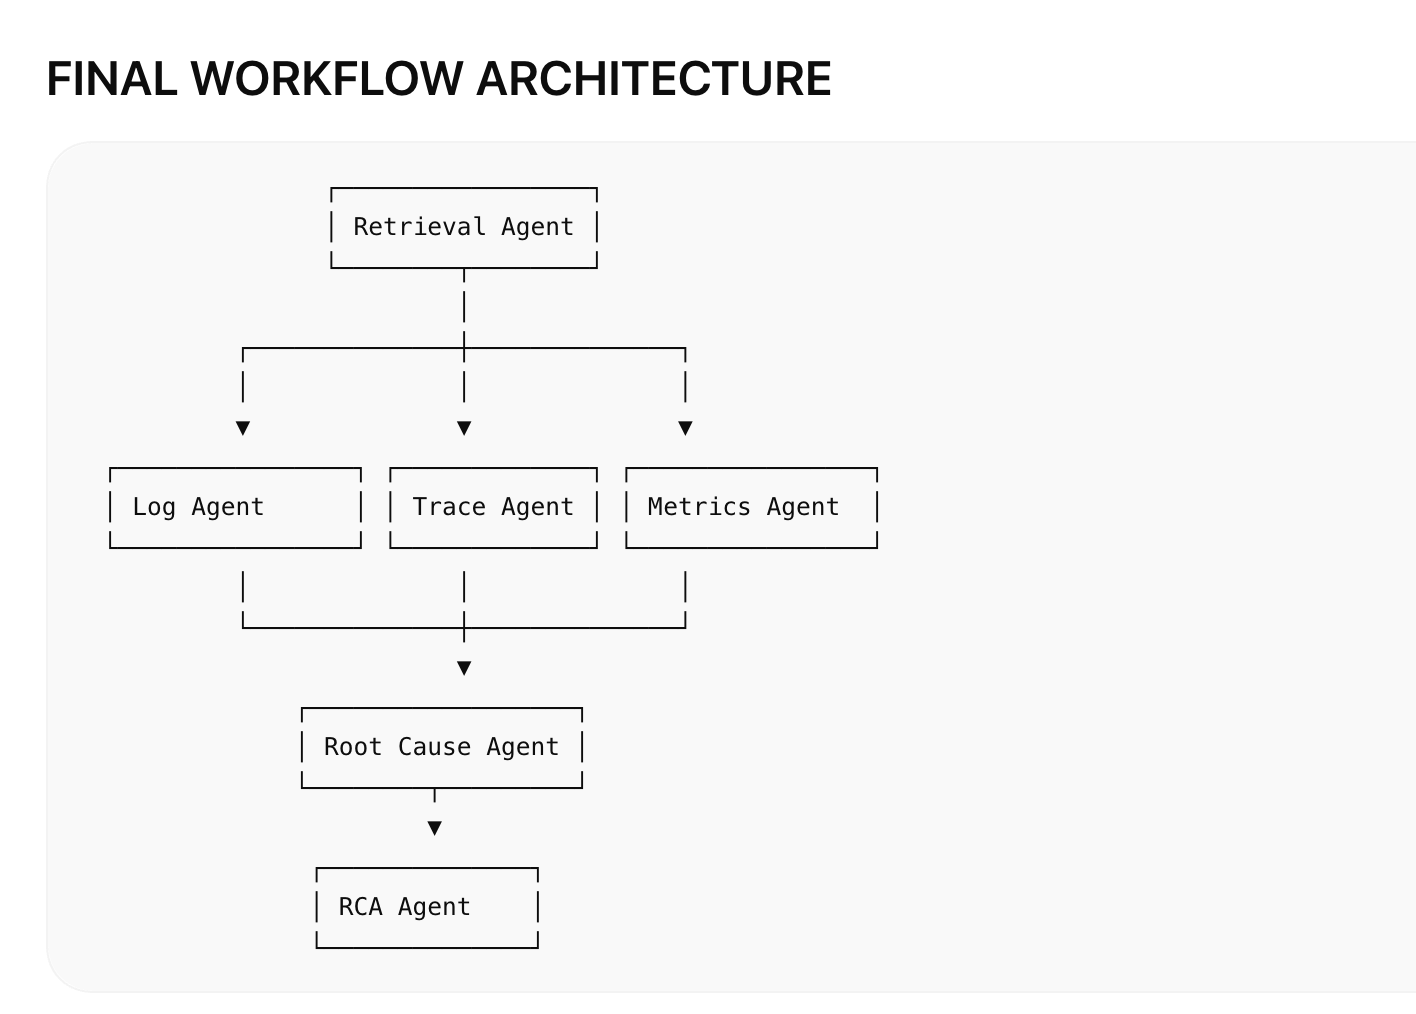

In [31]:
from langgraph.graph import StateGraph, END
workflow = StateGraph(DebuggingState) # Re-initialize workflow to force recompilation (v2)
workflow.add_node(
    "retrieval_agent",
    retrieval_agent
)
workflow.add_node(
    "log_analysis_agent",
    log_analysis_agent
)
workflow.add_node(
    "trace_analysis_agent",
    trace_analysis_agent
)
workflow.add_node(
    "metrics_analysis_agent",
     metrics_analysis_agent
)
workflow.add_node(
    "stacktrace_analysis_agent",
     stacktrace_analysis_agent

)
workflow.add_node(
    "root_cause_agent",
    root_cause_agent
)
workflow.add_node(
    "rca_agent",
    rca_agent
)

#Define Entry Point
workflow.set_entry_point(
    "retrieval_agent"
)

Add Parallel Execution

In [32]:
workflow.add_edge(
    "retrieval_agent",
    "log_analysis_agent"
)
workflow.add_edge(
    "retrieval_agent",
    "trace_analysis_agent"
)
workflow.add_edge(
    "retrieval_agent",
    "metrics_analysis_agent"
)
workflow.add_edge(
    "retrieval_agent",
    "stacktrace_analysis_agent"
) # Re-adding comment to force re-execution (v2)

Merge Into Root Cause Agent

In [33]:
workflow.add_edge(
    "log_analysis_agent",
    "root_cause_agent"
)
workflow.add_edge(
    "trace_analysis_agent",
    "root_cause_agent"
)
workflow.add_edge(
    "metrics_analysis_agent",
    "root_cause_agent"
)
workflow.add_edge(
    "stacktrace_analysis_agent",
    "root_cause_agent"
)

#Add RCA Generation
workflow.add_edge(
    "root_cause_agent",
    "rca_agent"
)

#Define Workflow End
workflow.add_edge(
    "rca_agent",
    END
)

#Compile Graph (forcing re-compilation)
app = workflow.compile()
# Ensuring full re-compilation after all agent definitions - additional comment to force (v2)

In [34]:
#Run Workflow

initial_state = {
    "user_query": "payment service database timeout",
    "retrieved_docs": [],
    "log_analysis": "",
    "trace_analysis": "",
    "metrics_analysis": "",
    "stacktrace_analysis": "",
    "root_cause": "",
    "recommendations": "", # Added missing 'recommendations' field
    "final_report": ""
}

result = app.invoke(initial_state)
#print(json.dumps(result,indent=2))
print(result["final_report"])

*   **Incident Summary:**
    The system is experiencing a P1 Critical incident characterized by widespread Database Connection Timeouts and significant Kafka Consumer Lag. This has led to severe degradation of core application functionality, critical data processing delays, and potential instability across the system, directly impacting end-users and downstream systems.

*   **Root Cause:**
    The most probable root cause is a combination of resource contention and performance bottlenecks across critical components, specifically:

    *   **For Database Connection Timeouts:**
        *   Slow-running SQL queries: Inefficient queries, missing indexes, or complex operations are holding database connections for too long.
        *   Database server overload: The database server itself is struggling with high CPU, memory, or I/O, leading to slow query execution and delays in accepting new connections.
        *   Application-side connection pool exhaustion: The application's database con